In [1]:

import cv2
import numpy as np



imagen = cv2.imread('iphone14.jpeg')


I = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)


canny = cv2.Canny(I,25,150)
#se reciben los valores d eumbral los bajos y los altos.

#un problema del canny es que nos deja linea smuy delgadas como vimos.
#por lo cual se utilizara un concepto que se llama dilatacion.
#haciendo los pixles de 255 mas grandes.

#por lo cual necesitamos un kernel


kernel = np.ones((5,5),np.uint8)
#voy a crear una matriz de 5*5 y que me devuelva un entero de 8 bits.

bordesdilatados = cv2.dilate(canny,kernel)


#queremos reslatar la imagen por lo que requeriremos rellenar los contorno y darle 255
# a todo lo que este dentro.

contornos,_ = cv2.findContours(bordesdilatados,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)


objetos = bordesdilatados.copy()
#Hacemos una copia por que se va a rescribir la variable con la siguiente funcion.


#Queremos que dibije el contorno d emayor area.
cv2.drawContours(objetos,[max(contornos,key=cv2.contourArea)],-1,255,thickness=-1)
#nuetsra llave es aquella que tiene el area maxima.
#el 255 es que le estamos diciendo que rellene el area de blanco.


#vamos a hace runa mascara

objetos = objetos/255

segmentada= np.zeros(imagen.shape)

segmentada[:,:,0]= objetos*imagen[:,:,0]+255*(objetos==0)
#dejenme en cero todo lo que no pertenezca a la imagen
# para cambiar el color del fondo +255*(objeto==0)

segmentada[:,:,1]= objetos*imagen[:,:,1]+255*(objetos==0)

segmentada[:,:,2]= objetos*imagen[:,:,2]+255*(objetos==0)

segmentada = np.uint8(segmentada)







In [2]:
segmentada

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

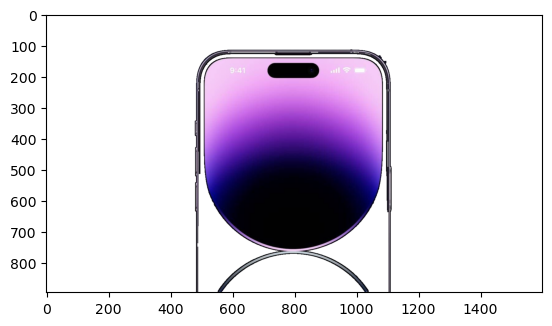

In [3]:
import matplotlib.pyplot as plt


segmentada_rgb = cv2.cvtColor(segmentada, cv2.COLOR_BGR2RGB)

plt.imshow(segmentada_rgb)
plt.show()

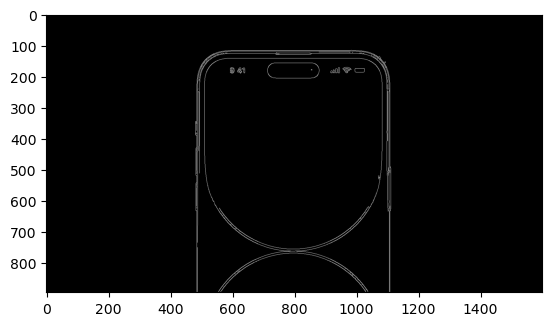

In [4]:
import matplotlib.pyplot as plt


canni_rgb = cv2.cvtColor(canny, cv2.COLOR_BGR2RGB)

plt.imshow(canni_rgb)

plt.show()

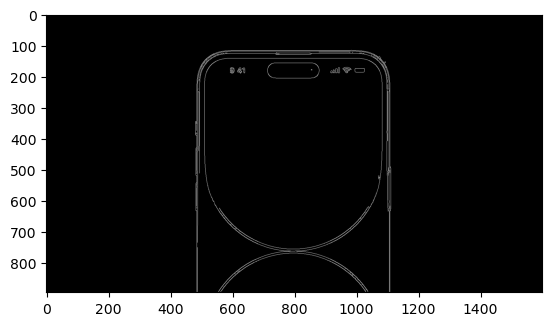

In [5]:
import matplotlib.pyplot as plt


canni_rgb = cv2.cvtColor(canny, cv2.COLOR_BGR2RGB)

plt.imshow(canni_rgb)

plt.show()